import numpy as np
import pandas as pd


In [1]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2047,ham,No de. But call me after some time. Ill tell y...,NaN,NaN,NaN
3646,ham,"Hey babe, my friend had to cancel, still up fo...",NaN,NaN,NaN
2596,ham,No i'm not gonna be able to. || too late notic...,NaN,NaN,NaN
3919,spam,FREE>Ringtone! Reply REAL or POLY eg REAL1 1. ...,NaN,NaN,NaN
2996,ham,Don know..he is watching film in computer..,NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

In [ ]:
#we follow the below steps to build our model
#1. Data cleaning
#2. EDA
#3. Text Preprocessing
#4. Model Building
#5. Evaluation
#6. Improvement
#7. Website
# Deployment

1.Data Cleaning

In [10]:
#At first i check extra 3 unamed columns have any name or not , or cane we drop them or not
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [ ]:
#above we see that the 3 unnamed columns have very less amount of data like, 50, 12, 6 non null values so we can drop those columns
#drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


KeyError: "['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] not found in axis"

In [19]:
df.sample(5)

,v1,v2
667,ham,This pay is &lt;DECIMAL&gt; lakhs:)
3261,ham,O shore are you takin the bus
5163,ham,Ok leave no need to ask
5380,ham,Its sunny in california. The weather's just cool
110,ham,What is the plural of the noun research?


In [20]:
#rename the columns so that we can understand it better
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text
5074,spam,"This is the 2nd attempt to contract U, you hav..."
4601,ham,\Hey j! r u feeling any better
59,ham,Yes..gauti and sehwag out of odi series.
257,ham,Where are you lover ? I need you ...
3460,ham,K.. I yan jiu liao... Sat we can go 4 bugis vi...


In [ ]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 6.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.1 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 3.9 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 3.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 3.0 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.0 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 2.9 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 3.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 3.0 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Ml mode l can only understand the numerical values but our #target column have categorical values ham and spam so we #need to convert those categorical values into numerical #values ham =0 and spam =1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
#head is used to see the top 5 rows of the dataframe in pandas
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#check missing values in the dataset
df.isnull().sum()
#there are no missing values in the dataset

target    0
text      0
dtype: int64

In [ ]:
#chekc duplicated values in the dataset
df.duplicated().sum()
#there are 0 duplicated values in the dataset so we have successfully removed the duplicated values

np.int64(0)

In [ ]:
#remove duplicated values
#keep = first means we will keep the first occurrence of the duplicated value and drop the rest
df = df.drop_duplicates(keep='first')

In [36]:
#again check duplicated values in the dataset
df.duplicated().sum()

np.int64(0)

In [37]:
#after removing duplicated values we have total 5169 rows and 2 columns in the dataset
df.shape

(5169, 2)

2.EDA

In [38]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [41]:
#check how many ham and spam messages are there in the #dataset
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

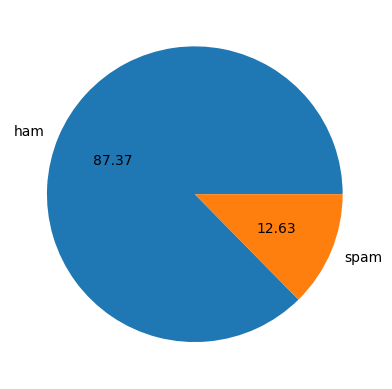

In [ ]:
#visualization of ham and spam messages using pie chart
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()
#data is imbalanced because we have more ham messages than spam messages in the dataset

In [44]:
pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 905.6 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.6 MB 905.6 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.6 MB 934.2 kB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 978.0 kB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.1 MB/s  0:00:01

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
#we create 3 columns in the dataset for deeper analysis of the text data
#1. num_characters: number of characters in the text message
#2. num_words: number of words in the text message
#3. num_sentences: number of sentences in the text message
#to do this we need nltk library
#nltk is a natural language processing library in python which is used for text preprocessing and analysis
import nltk
#punkt is a pre-trained model in nltk which is used for tokenization of sentences and words
#we need to download the punkt model to load data into our model
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
#count number of characters in the text message in text column and store it in num_characters column
df['num_characters'] = df['text'].apply(len)

In [51]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
#tokenize the text message into numbers and then count the number of words in the text message and store it in num_words column

#count number of words in the text message in text column and store it in num_words column

#nltk.word_tokenize is used to tokenize the text message into words and then we count the number of words in the text message

#lambda is an anonymous function in python which is used to create a function without a name

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [59]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [67]:
#tokenize the text message into sentences and then count the number of sentences in the text message and store it in num_sentences column

#sent-tokenize is used to tokenize the text message into sentences and then we count the number of sentences in the text message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
#here describe is used to get the statistical summary of the numerical columns in the dataset
df[['num_characters', 'num_words', 'num_sentences']].describe

<bound method NDFrame.describe of       num_characters  num_words  num_sentences
0                111         24              2
1                 29          8              2
2                155         37              2
3                 49         13              1
4                 61         15              1
...              ...        ...            ...
5567             161         35              4
5568              37          9              1
5569              57         15              2
5570             125         27              1
5571              26          7              2

[5169 rows x 3 columns]>